In [91]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings 
import joblib
warnings.filterwarnings('ignore')

In [92]:
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

In [93]:
train=pd.read_csv('../data/train.csv')
test=pd.read_csv('../data/test.csv')

In [94]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [95]:
train.describe()


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [96]:
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [97]:
train.isnull().sum()


PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [98]:
def preprocess(df):
    df['Family_size']=df['SibSp']+df['Parch']+1
    df['Sex']=df['Sex'].map({
        'male':1,
        'female':0
    })
    df["Title"] = df["Name"].str.extract(r",\s*([^.]*)\.")
    df['Age']=df['Age'].fillna(df.groupby('Title')['Age'].transform('median'))
    df['Age']=df['Age'].fillna(df['Age'].median())
    df["Embarked"]=df['Embarked'].fillna("S")
    df["Embarked"]=df['Embarked'].map({
        "S":1,
        "C":2,
        "Q":3
        })
    df["Cabin"]=df['Cabin'].fillna("unknown")
    df['Fare']=df['Fare'].fillna(df['Fare'].median())


    return df
    




In [99]:
test=preprocess(test)
train=preprocess(train)

In [100]:
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Family_size,Title
0,1,0,3,"Braund, Mr. Owen Harris",1,22.0,1,0,A/5 21171,7.2500,unknown,1,2,Mr
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,38.0,1,0,PC 17599,71.2833,C85,2,2,Mrs
2,3,1,3,"Heikkinen, Miss. Laina",0,26.0,0,0,STON/O2. 3101282,7.9250,unknown,1,1,Miss
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,35.0,1,0,113803,53.1000,C123,1,2,Mrs
4,5,0,3,"Allen, Mr. William Henry",1,35.0,0,0,373450,8.0500,unknown,1,1,Mr


In [101]:
train.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       0
Family_size    0
Title          0
dtype: int64

In [102]:
pclass_survival=train.groupby('Pclass')['Survived'].mean()
sex_survival=train.groupby('Sex')['Survived'].mean()
family_survival=train.groupby('Family_size')['Survived'].mean()
age_survival=train.groupby('Age')['Survived'].mean()



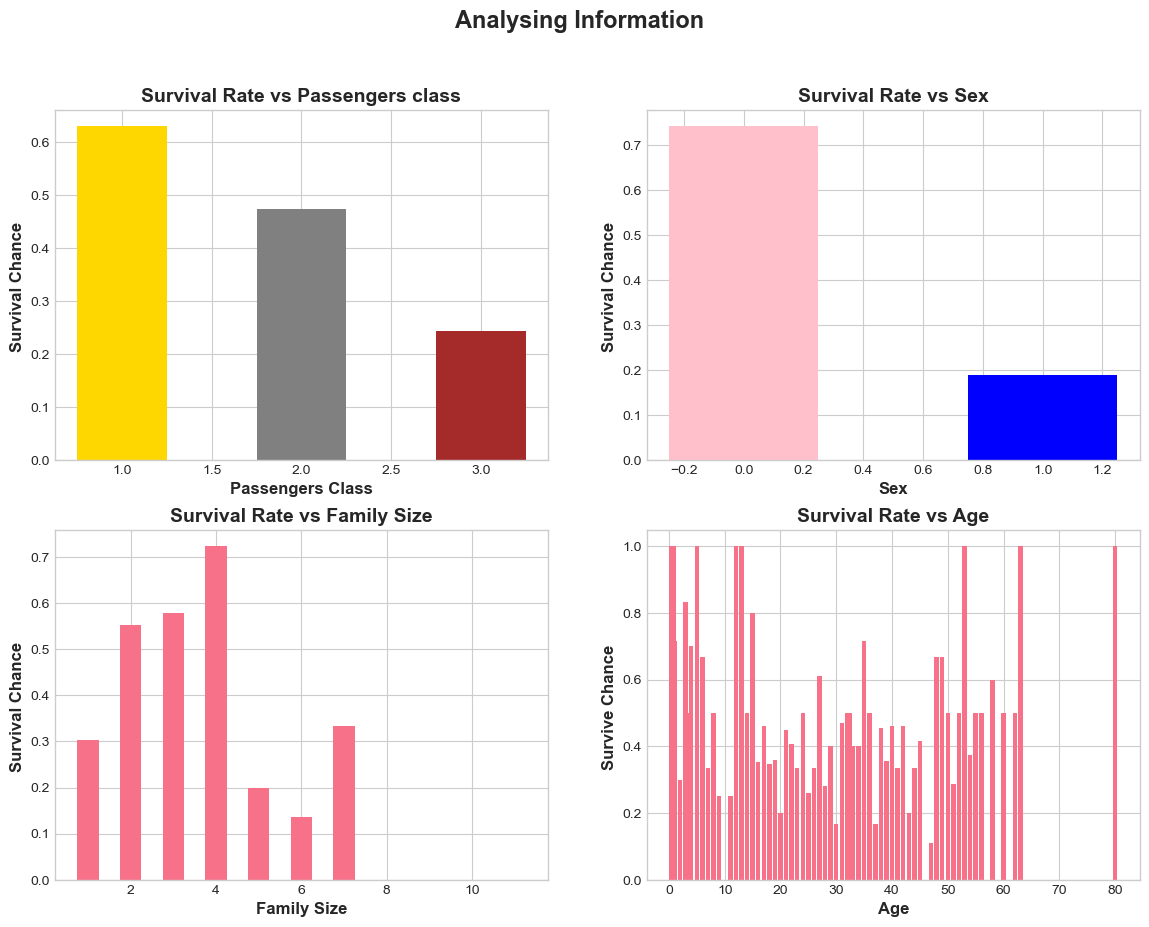

In [103]:
fig,axes= plt.subplots(2,2, figsize=(14,10))
fig.suptitle('Analysing Information',fontweight='bold',fontsize=17)

axes[0,0].bar(pclass_survival.index,pclass_survival.values,color=['gold','grey','brown'],width=0.5)
axes[0,0].set_title("Survival Rate vs Passengers class",fontweight='bold',fontsize=14)
axes[0,0].set_xlabel("Passengers Class",fontweight='bold',fontsize=12)
axes[0,0].set_ylabel("Survival Chance ",fontweight='bold',fontsize=12)

axes[0,1].bar(sex_survival.index,sex_survival.values,color=['pink','blue'],width=0.5)
axes[0,1].set_title("Survival Rate vs Sex",fontweight='bold',fontsize=14)
axes[0,1].set_xlabel("Sex",fontweight='bold',fontsize=12)
axes[0,1].set_ylabel("Survival Chance ",fontweight='bold',fontsize=12)

axes[1,0].bar(family_survival.index,family_survival.values,width=0.5)
axes[1,0].set_title("Survival Rate vs Family Size",fontweight='bold',fontsize=14)
axes[1,0].set_xlabel("Family Size",fontweight='bold',fontsize=12)
axes[1,0].set_ylabel("Survival Chance ",fontweight='bold',fontsize=12)

axes[1,1].bar(age_survival.index,age_survival.values)
axes[1,1].set_title("Survival Rate vs Age",fontweight='bold',fontsize=14)
axes[1,1].set_xlabel("Age",fontweight="bold",fontsize=12)
axes[1,1].set_ylabel("Survive Chance ",fontweight='bold',fontsize=12)
plt.savefig('../image/factor_effecting_survival',dpi=150,bbox_inches='tight')
plt.show()

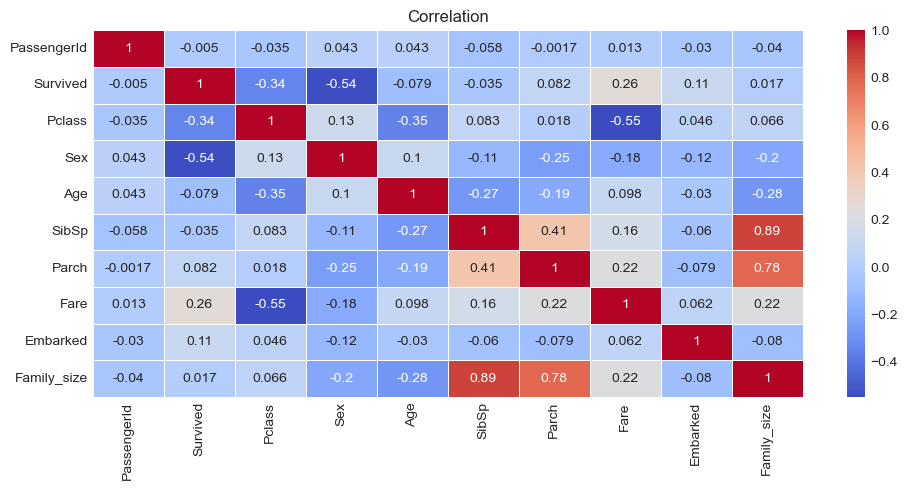

<Figure size 640x480 with 0 Axes>

In [104]:
plt.figure(figsize=(10,5))
correlation=train.select_dtypes(include='number')
correlation=correlation.corr()
sns.heatmap(correlation,annot=True, cmap="coolwarm", linewidths=0.5)
plt.title("Correlation")
plt.tight_layout()
plt.show()
plt.savefig('../image/correlation_heatmap',dpi=150,bbox_inches='tight')

In [106]:
X_train=train[['Pclass','Sex','Family_size','Embarked','Age','Fare']]
y=train['Survived']
X_test=test[['Pclass','Sex','Family_size','Embarked','Age','Fare']]

In [107]:
X_test.isna().sum()

Pclass         0
Sex            0
Family_size    0
Embarked       0
Age            0
Fare           0
dtype: int64

In [108]:
from sklearn.linear_model import LogisticRegression

In [109]:
model=LogisticRegression()
model.fit(X_train,y)
prediction=model.predict(X_test)

In [110]:
print(prediction)

[0 0 0 0 1 0 1 0 1 0 0 0 1 0 1 1 0 0 1 0 0 0 1 1 1 0 1 0 0 0 0 0 0 0 1 0 1
 1 0 0 0 1 0 1 1 0 0 0 1 0 1 0 1 1 0 0 0 0 0 1 0 0 0 1 1 1 1 0 1 1 1 0 1 1
 1 1 0 1 0 1 0 0 0 0 0 0 1 1 1 0 1 0 1 0 1 0 1 0 1 0 1 0 0 0 1 0 0 0 0 0 0
 1 1 1 1 0 0 1 1 1 1 0 1 0 0 1 0 1 0 0 0 0 0 0 0 0 0 0 1 0 0 1 0 0 0 0 1 0
 1 0 1 0 0 0 0 0 1 1 0 1 1 0 1 0 0 1 0 0 1 1 0 0 0 0 0 1 1 0 1 1 0 0 1 0 1
 0 1 0 0 0 0 1 0 0 0 0 1 1 0 1 1 0 0 1 0 1 1 0 1 0 0 0 0 1 0 0 1 0 1 0 1 0
 1 0 1 0 0 1 0 0 0 1 0 0 0 0 0 0 1 1 1 1 0 0 0 0 1 0 1 1 1 0 1 0 0 0 0 0 1
 0 0 0 1 1 0 0 0 0 1 0 0 0 1 1 0 1 0 0 0 0 1 0 1 1 1 0 0 1 0 0 1 1 0 0 0 0
 1 0 1 0 0 0 0 0 1 1 0 0 0 0 0 0 0 1 1 1 0 0 0 0 0 0 0 0 1 0 1 0 0 0 1 0 0
 1 0 0 0 0 0 0 0 0 0 1 0 1 0 1 0 1 1 0 0 0 1 0 1 0 0 1 0 1 1 0 1 0 0 1 1 0
 0 1 0 0 1 1 1 0 0 0 0 0 1 1 0 1 0 0 0 0 1 1 0 0 0 1 0 1 0 0 1 0 1 1 0 0 0
 0 1 1 1 1 1 0 1 0 0 0]


In [111]:
result=pd.DataFrame({
    "PassengerId": test["PassengerId"],
    "Survived": prediction
})



In [112]:
joblib.dump(model,"../model/survival_prediction.pkl")

['../model/survival_prediction.pkl']

In [113]:
result.to_csv("../result/submission.csv",index=False)